# Where SLM made biodiversity worse: the negative cases

Every other notebook in this repository asks what makes the reported biodiversity impact of a
Sustainable Land Management technology **large**. This one turns the question over and looks at the
other tail: the technologies whose compiler reported that biodiversity got *worse*.

Out of 1,540 documented technologies, 895 carry a biodiversity rating and **41 of them average below
zero** — 4.6 % of the rated corpus. This notebook presents those cases: **country, the biodiversity
score, a short description and the photographs**, five of them in full.

Two things to know before the numbers, because both decide *which* five cases are worth showing:

* **Two of the eight indicators run backwards for some compilers.** On *pest / disease control* and
  *invasive alien species* a negative number sometimes means "there are fewer pests now" — a good
  outcome written down as −3. Section 3 shows the evidence. Cases that are negative only on those
  two cannot be read as harm, and 28 of the 41 are exactly that.
* **Most negatives rest on a single answer.** 29 of the 41 come from one rated indicator out of
  eight. One tick is not a finding, so the cases shown rest on at least two.

After both filters, **15 technologies are negative on the six indicators whose sign is unambiguous**,
and section 4 presents the five strongest of them.

**Data:** the tidy tables built by `wocat_api/fetch.py` (`wocat_api/README.md` explains the chain
from the API to the CSVs), the 320×240 thumbnails in the shared photo cache, and the cached
questionnaires for the free text the CSVs drop. Nothing is modelled here — this notebook reads the
corpus and shows it.

## 1. Setup

In [1]:
import base64, io, json, pathlib, warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import HTML, display

from wocat_api.transform import INDICATOR_LABELS, i18n   # run this notebook from the repo root

warnings.filterwarnings("ignore")

# --- the shared wocat data folder, wherever this notebook was opened from --------------------
DATA = next((p for p in (pathlib.Path(c).resolve()
                         for c in ["../wocat/data", "../../wocat/data", "wocat/data", "data"])
             if (p / "processed").exists()), None)
assert DATA is not None, "could not find the wocat data folder - see wocat_api/README.md"
PROC, RAW = DATA / "processed", DATA / "raw"
THUMBS = RAW / "images_thumb"                        # 320x240 webp named <image_id>.webp
RECORDS = RAW / "technologies"                       # one questionnaire per file, <id>.json
CACHE = pathlib.Path.cwd() / "cache" / "neg_thumbs"  # thumbnails this notebook fetches itself
CACHE.mkdir(parents=True, exist_ok=True)

record_url = "https://wocat.net/en/database/technologies/{}/".format   # the public WOCAT page

# --- palette ---------------------------------------------------------------------------------
# The impact score has a sign, so the colour scale is diverging: a red arm for "reported worse",
# a blue arm for "reported better", a neutral grey at zero. Each arm is a validated ordinal ramp
# (one hue, monotone lightness). The two palest steps sit below 3:1 against the surface, so every
# mark in this notebook also carries its printed value - colour never has to carry meaning alone.
SCALE = {-3: "#a6272a", -2: "#e34948", -1: "#f1968e", 0: "#f0efec",
          1: "#86b6ef",  2: "#3987e5",  3: "#1c5cab"}
C_BLUE, C_ORANGE = "#2a78d6", "#eb6834"      # the two categorical slots sections 3 needs
SURFACE, INK, INK_SOFT = "#fcfcfb", "#0b0b0b", "#52514e"
MUTED, GRID, AXIS = "#898781", "#e1e0d9", "#c3c2b7"

plt.rc("figure", dpi=130, facecolor=SURFACE)
plt.rc("savefig", facecolor=SURFACE)
plt.rc("axes", facecolor=SURFACE, edgecolor=AXIS, labelcolor=INK, titlesize=11,
       labelsize=9.5, axisbelow=True)
plt.rc("axes.spines", top=False, right=False)
plt.rc("grid", color=GRID, linewidth=0.8)
plt.rc("xtick", color=MUTED, labelsize=9)
plt.rc("ytick", color=MUTED, labelsize=9)
plt.rc("font", size=9.5)
plt.rc("legend", frameon=False, fontsize=9)

# The cards in section 4 pin their own light surface and ink, so they read the same whether the
# notebook is opened under a light or a dark editor theme.

print("data folder :", DATA)
print("thumbnails  :", f"{len(list(THUMBS.glob('*.webp'))):,} on disk" if THUMBS.is_dir()
      else "none on disk - they will be fetched from wocat.net on demand")
print("records     :", f"{len(list(RECORDS.glob('*.json'))):,} questionnaires")

data folder : /Users/nsdav/Study/CAS AML/Projects/wocat/data
thumbnails  : 4,395 on disk
records     : 1,540 questionnaires


## 2. What "biodiversity below zero" means

Section 6.1 of the [WOCAT questionnaire](https://wocat.net/documents/447/QT_English_2019_CClicence.docx)
asks the compiler to rate the on-site biodiversity effect of the technology on **eight indicators**,
each from **−3 (much worse) to +3 (much better)**, and to leave out any indicator they consider
irrelevant. A technology therefore carries between zero and eight scores. `biodiversity_score_mean`
is the row mean of whichever were rated, and a **negative case** is a technology whose mean falls
below zero.

The corpus is overwhelmingly positive, which is what makes the negative tail interesting: these are
compilers writing down a bad outcome for a practice they chose to document.

In [2]:
tech   = pd.read_csv(PROC / "technologies_biodiversity.csv")
long   = pd.read_csv(PROC / "biodiversity_impacts_long.csv")
images = pd.read_csv(PROC / "images_index.csv")

scored   = tech[tech.n_biodiversity_indicators_rated > 0]
negative = tech[tech.biodiversity_score_mean < 0].copy()

print(f"technologies in the corpus         : {len(tech):,}")
print(f"  with at least one bio indicator  : {len(scored):,}")
print(f"  mean score below 0               : {len(negative):,}   ({len(negative) / len(scored):.1%} of the rated)")
print(f"  mean score exactly 0             : {int((scored.biodiversity_score_mean == 0).sum()):,}")
print(f"  mean score above 0               : {int((scored.biodiversity_score_mean > 0).sum()):,}")
print()
print(f"individual indicator scores        : {len(long):,}, of which {int((long.value < 0).sum()):,} are negative")
print()
print("the 41 negative cases rest on this many rated indicators:")
print(negative.n_biodiversity_indicators_rated.value_counts().sort_index()
      .rename_axis("indicators rated").rename("technologies").to_frame().to_string())

technologies in the corpus         : 1,540
  with at least one bio indicator  : 895
  mean score below 0               : 41   (4.6% of the rated)
  mean score exactly 0             : 31
  mean score above 0               : 823

individual indicator scores        : 2,525, of which 118 are negative

the 41 negative cases rest on this many rated indicators:
                  technologies
indicators rated              
1                           29
2                            4
3                            3
4                            3
5                            1
6                            1


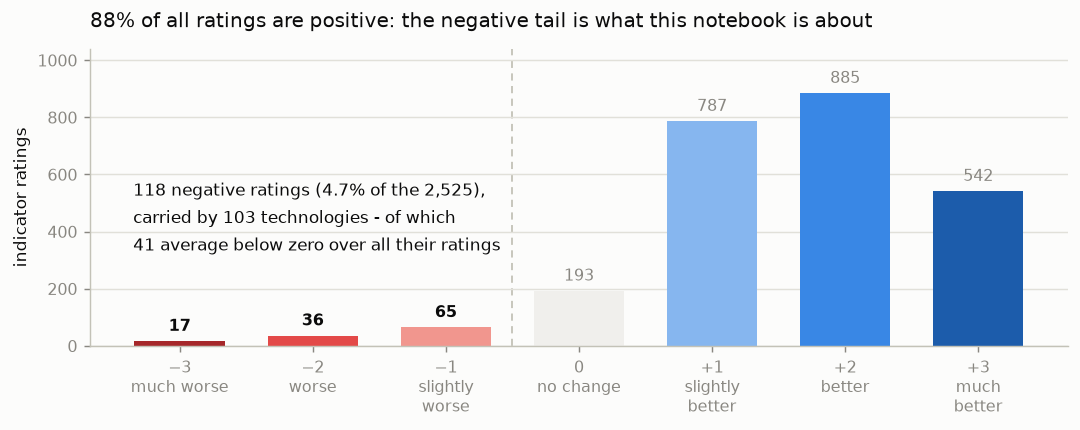

In [3]:
# The -3..+3 distribution of all 2,525 individual ratings, on the diverging scale.
fig, ax = plt.subplots(figsize=(8.4, 3.4))
counts = long.value.value_counts().reindex(range(-3, 4), fill_value=0)
ax.bar(counts.index, counts.values, width=0.68, color=[SCALE[v] for v in counts.index])
for v, n in counts.items():
    ax.text(v, n + 22, f"{n:,}", ha="center", va="bottom", fontsize=9,
            color=INK if v < 0 else MUTED, fontweight="bold" if v < 0 else "normal")

ax.axvline(-0.5, color=AXIS, linewidth=1, linestyle=(0, (4, 3)), zorder=0)
ax.text(-3.35, 590, f"{int((long.value < 0).sum()):,} negative ratings "
                    f"({(long.value < 0).mean():.1%} of the {len(long):,}),\n"
                    f"carried by {long[long.value < 0].technology_id.nunique()} technologies - of which\n"
                    f"{len(negative)} average below zero over all their ratings",
        ha="left", va="top", fontsize=9.5, color=INK, linespacing=1.6)
ax.set_xticks(range(-3, 4))
ax.set_xticklabels(["−3\nmuch worse", "−2\nworse", "−1\nslightly\nworse", "0\nno change",
                    "+1\nslightly\nbetter", "+2\nbetter", "+3\nmuch\nbetter"])
ax.set_ylabel("indicator ratings")
ax.set_ylim(0, 1040)
ax.grid(True, axis="y"); ax.grid(False, axis="x")
ax.set_title(f"{(long.value > 0).mean():.0%} of all ratings are positive: the negative tail is what this notebook is about",
             loc="left", color=INK, pad=12)
plt.tight_layout(); plt.show()

## 3. Two indicators whose sign runs backwards

Before picking cases to present, one data problem has to be settled, because it decides which cases
mean what they appear to mean.

Six of the eight indicators — vegetation cover, above-ground biomass, plant diversity, animal
diversity, habitat diversity, beneficial species — are worded so that **more is better**, and a
negative score unambiguously says biodiversity got worse. The other two, **pest / disease control**
and **invasive alien species**, are not read the same way by every compiler. Some rate the
*quality of the control* (worse control → negative). Others rate the *quantity of the bad thing*,
so "we cleared the plot of weeds" gets written down as −3.

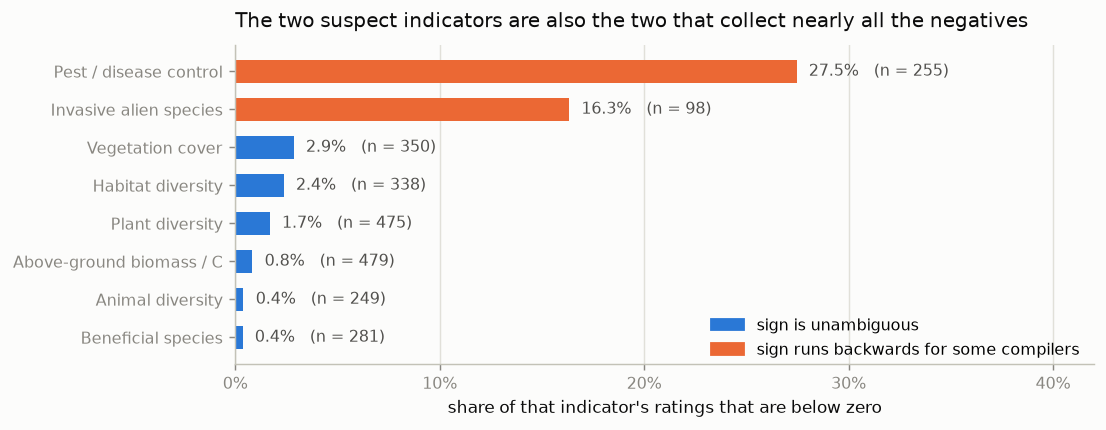

In [4]:
DIRECT = ["vegetation_cover", "biomass_above_ground_C", "plant_diversity",
          "animal_diversity", "habitat_diversity", "beneficial_species"]
AMBIGUOUS = ["pest_disease_control", "invasive_alien_species"]
GROUP_COLOUR = {"sign is unambiguous": C_BLUE, "sign runs backwards for some compilers": C_ORANGE}

share = (long.assign(neg=long.value < 0).groupby("indicator")
             .agg(negative_share=("neg", "mean"), n=("value", "size"))
             .reindex(DIRECT + AMBIGUOUS))
share["group"] = ["sign is unambiguous"] * len(DIRECT) + ["sign runs backwards for some compilers"] * len(AMBIGUOUS)
order = share.sort_values("negative_share")

fig, ax = plt.subplots(figsize=(8.6, 3.4))
labels = [INDICATOR_LABELS[i] for i in order.index]
ax.barh(labels, order.negative_share * 100, height=0.62, color=[GROUP_COLOUR[g] for g in order.group])
for label, row in zip(labels, order.itertuples()):
    ax.text(row.negative_share * 100 + 0.6, label, f"{row.negative_share:.1%}   (n = {int(row.n)})",
            va="center", fontsize=9, color=INK_SOFT)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in GROUP_COLOUR.values()]
ax.legend(handles, GROUP_COLOUR.keys(), loc="lower right", bbox_to_anchor=(1.0, -0.03))
ax.set_xlim(0, 42)
ax.set_xticks(range(0, 41, 10))
ax.set_xticklabels([f"{t}%" for t in range(0, 41, 10)])
ax.set_xlabel("share of that indicator's ratings that are below zero")
ax.grid(True, axis="x"); ax.grid(False, axis="y")
ax.set_title("The two suspect indicators are also the two that collect nearly all the negatives",
             loc="left", color=INK, pad=10)
plt.tight_layout(); plt.show()

Pest / disease control is negative in **27 %** of its ratings and invasive alien species in **16 %**,
against 0.4–2.9 % for each of the other six. Either those two really do get worse an order of
magnitude more often than everything else, or they are being scored on a different axis. The
compilers' own comments settle it.

In [5]:
# The compilers' own words on their own negative scores, on the two suspect indicators.
EXAMPLES = [(1524, "pest_disease_control"), (1151, "pest_disease_control"), (1223, "pest_disease_control"),
            (6821, "pest_disease_control"), (6668, "invasive_alien_species"), (4233, "pest_disease_control"),
            (7366, "pest_disease_control"), (6236, "pest_disease_control"), (2255, "pest_disease_control")]
keyed = long.set_index(["technology_id", "indicator"])

print("A negative score on 'pest / disease control' or 'invasive alien species', as the compiler explained it:\n")
for technology_id, indicator in EXAMPLES:
    row = keyed.loc[(technology_id, indicator)]
    print(f"  {row.value:+d}  {row.country_name:<12} {' '.join(str(row.comment).split())[:96]}")

# how many of the 41 owe their negative mean entirely to those two indicators
direct_mean = long[long.indicator.isin(DIRECT)].groupby("technology_id").value.mean()
direct_negative_ids = set(direct_mean[direct_mean < 0].index)
ambiguous_only = sorted(set(negative.technology_id) - direct_negative_ids)
print(f"\n{len(ambiguous_only)} of the {len(negative)} negative cases are negative only because of these two indicators.")

A negative score on 'pest / disease control' or 'invasive alien species', as the compiler explained it:

  -3  Ethiopia     new habitat for rodents etc.
  -2  Uganda       They create hiding places for rats
  -3  Cambodia     Problems with insects
  -1  Bhutan       Water harvesting pond acts as a suitable habitat for mosquitoes therefore increasing the risk of
  -3  Tunisia      Purification of the plot from pest plants
  -1  Thailand     Reduced pests/ diseases
  -3  India        The farmer says he doesn't know what are pests now which was not the case earlier. Earlier his c
  -2  Sri Lanka    Reduced application of chemical fertilizer had led to less succulent crops and increased resista
  -1  Cambodia     Pests still occur but not many.

28 of the 41 negative cases are negative only because of these two indicators.


The first four read as harm — new habitat for rodents, hiding places for rats, problems with insects,
a pond breeding mosquitoes. The last five read as the **opposite**: the plot was cleared of weeds,
pests were reduced, the farmer no longer knows what pests are. Same sign, opposite meaning, and
nothing in the record distinguishes the two except a free-text comment, which most records do not
carry.

So those two indicators are dropped from the case selection. What remains is the question the
questionnaire can actually answer: **which technologies were rated negative on the six indicators
where a minus sign means biodiversity got worse?**

In [6]:
direct = long[long.indicator.isin(DIRECT)]
by_tech = direct.groupby("technology_id").value.agg(direct_mean="mean", direct_n="size")
cases = (by_tech[by_tech.direct_mean < 0]
         .join(tech.set_index("technology_id")[["name", "country_name", "landuse",
                                                "biodiversity_score_mean",
                                                "n_biodiversity_indicators_rated"]])
         .sort_values(["direct_mean", "direct_n"], ascending=[True, False]))

print(f"{len(cases)} technologies are negative on the six unambiguous indicators.\n")
print(cases.reset_index()[["technology_id", "country_name", "direct_mean", "direct_n",
                           "biodiversity_score_mean", "name"]]
      .rename(columns={"direct_mean": "mean of the six", "direct_n": "six rated",
                       "biodiversity_score_mean": "mean of all eight",
                       "country_name": "country", "name": "technology"})
      .round(2).to_string(index=False))

15 technologies are negative on the six unambiguous indicators.

 technology_id     country  mean of the six  six rated  mean of all eight                                                         technology
          1714     Germany            -3.00          2              -3.00                Drainage of coastal areas in north- western Germany
          3224       Haiti            -2.80          5              -2.80                                              Weeded/ ploughed crop
          6855      Bhutan            -2.00          3              -1.00                                       Managed Burning of Rangeland
          1289 Philippines            -2.00          1              -2.00                                                Vegetable Terracing
          2149      Uganda            -2.00          1              -2.00                                      Firelines For Tree Protection
          2825      Uganda            -2.00          1               0.00                

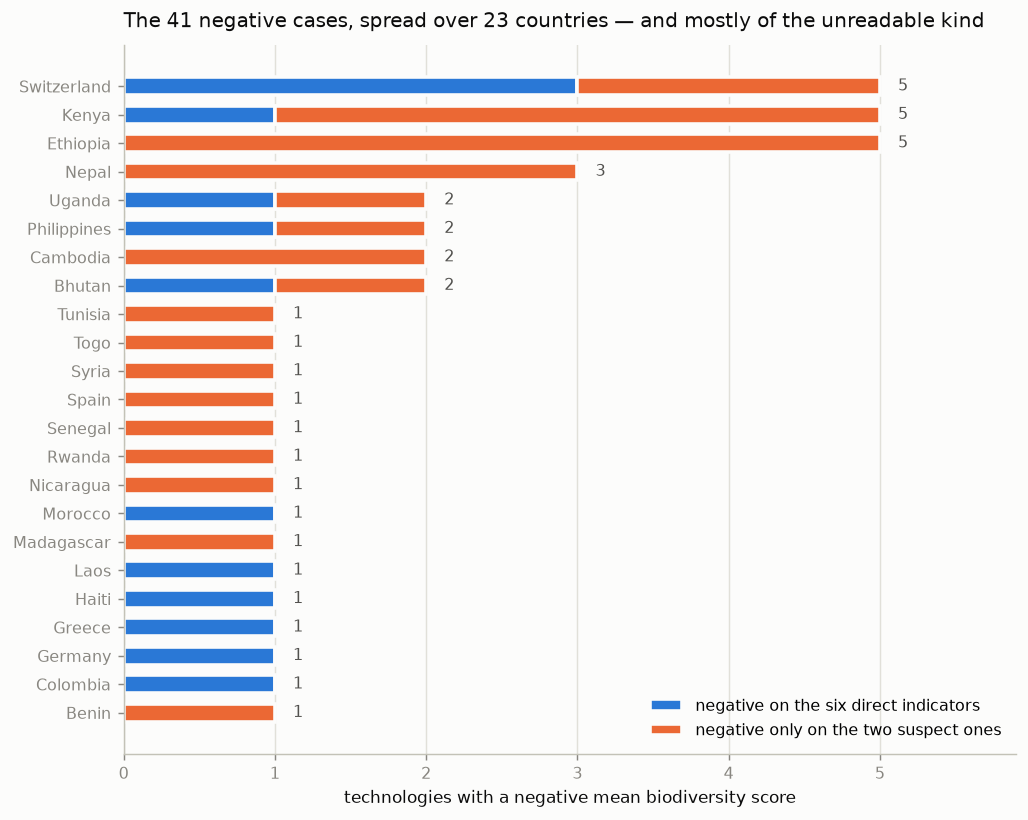

In [7]:
# The 41 by country, split by which indicators actually made them negative.
kind = np.where(negative.technology_id.isin(direct_negative_ids),
                "negative on the six direct indicators",
                "negative only on the two suspect ones")
split = (pd.crosstab(negative.country_name, kind)
           .reindex(columns=["negative on the six direct indicators", "negative only on the two suspect ones"],
                    fill_value=0))
split = split.loc[split.sum(axis=1).sort_values(kind="stable").index]

fig, ax = plt.subplots(figsize=(8.0, 6.4))
left = np.zeros(len(split))
for column, colour in zip(split.columns, (C_BLUE, C_ORANGE)):
    ax.barh(split.index, split[column], left=left, height=0.62, color=colour,
            label=column, edgecolor=SURFACE, linewidth=2)
    left += split[column].to_numpy()
for country, total in split.sum(axis=1).items():
    ax.text(total + 0.12, country, str(int(total)), va="center", fontsize=9, color=INK_SOFT)

ax.legend(loc="lower right")
ax.set_xlim(0, split.sum(axis=1).max() + 0.9)
ax.set_xticks(range(0, int(split.sum(axis=1).max()) + 1))
ax.set_xlabel("technologies with a negative mean biodiversity score")
ax.grid(True, axis="x"); ax.grid(False, axis="y")
ax.set_title(f"The 41 negative cases, spread over {len(split)} countries — and mostly of the unreadable kind",
             loc="left", color=INK, pad=10)
plt.tight_layout(); plt.show()

No country carries more than five of the 41, and fifteen carry exactly one, so a negative score is
not a property of a region — it is one compiler's judgement about one site. The orange in this chart
is the sign problem: in most countries, every negative case is one that cannot be read as harm.

Two of the fifteen readable cases — *Pine Woodlot* in Uganda and *Bush Thinning* in Namibia — do not
appear among the 41 at all, because a positive score on one of the two suspect indicators pulled
their eight-indicator mean back above zero. That is the same problem seen from the other side, and
another reason to read the six on their own.

## 4. Five cases in full

The selection rule, in one line: **of the technologies negative on the six unambiguous indicators,
the five most negative among those resting on at least two ratings.** The minimum of two is the point
of the rule — it drops the cases that come down to a single tick on a single question. What it keeps
are records where the compiler rated several aspects of biodiversity and marked most of them down.
Both numbers are parameters of the cell below; change them and the cards change.

Each card carries what was asked for: **country**, the **biodiversity score** (the headline number,
plus every individual indicator with its sign), a **short description** — WOCAT's own one-sentence
definition of the technology, followed by the compiler's comment on each negative rating where one
exists — and the **photographs** from the record, with their captions.

In [8]:
MIN_INDICATORS = 2    # a case must rest on at least this many of the six, not a single tick
N_CASES        = 5

selected = cases[cases.direct_n >= MIN_INDICATORS].head(N_CASES)
print(f"{len(selected)} cases selected:\n")
print(selected.reset_index()[["technology_id", "country_name", "direct_mean", "direct_n", "name"]]
      .rename(columns={"direct_mean": "mean of the six", "direct_n": "six rated",
                       "country_name": "country", "name": "technology"}).round(2).to_string(index=False))

5 cases selected:

 technology_id     country  mean of the six  six rated                                                       technology
          1714     Germany            -3.00          2              Drainage of coastal areas in north- western Germany
          3224       Haiti            -2.80          5                                            Weeded/ ploughed crop
          6855      Bhutan            -2.00          3                                     Managed Burning of Rangeland
          2990       Kenya            -1.25          4 Makurian Group Ranch Grazing with Holistic Management Principles
          5838 Switzerland            -1.00          2                        Ackerbau Fruchtfolge auf anmoorigem Boden


In [9]:
def thumb_bytes(image_id, url=None):
    """The 320x240 webp for one photo: from the shared cache if it is there, else fetched once
    from wocat.net - the media server is public, no token - and kept in cache/neg_thumbs/."""
    for path in (THUMBS / f"{image_id}.webp", CACHE / f"{image_id}.webp"):
        if path.is_file():
            return path.read_bytes()
    if not isinstance(url, str) or not url:
        return None
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    (CACHE / f"{image_id}.webp").write_bytes(response.content)
    return response.content


def signed(value):
    """+2 / 0 / -3, never '+0'."""
    return f"{value:+d}" if value else "0"


def indicator_chart(scores):
    """The rated indicators of one technology as diverging bars, as a base64 PNG."""
    scores = scores.sort_values("value")
    fig, ax = plt.subplots(figsize=(4.6, 0.34 * len(scores) + 0.95))
    labels = [INDICATOR_LABELS[i] for i in scores.indicator]
    ax.barh(labels, scores.value, height=0.6, color=[SCALE[int(v)] for v in scores.value])
    for label, value in zip(labels, scores.value):
        ax.text(value + (0.18 if value >= 0 else -0.18), label, signed(value), va="center",
                ha="left" if value >= 0 else "right", fontsize=9, color=INK_SOFT, fontweight="bold")
    ax.axvline(0, color=AXIS, linewidth=1.1)
    ax.set_xlim(-3.7, 3.7); ax.set_xticks(range(-3, 4))
    ax.tick_params(axis="y", length=0)
    ax.grid(True, axis="x"); ax.grid(False, axis="y")
    ax.spines["left"].set_visible(False)
    ax.set_xlabel("much worse  ←   reported impact   →  much better", fontsize=8.5, color=MUTED)
    fig.tight_layout(pad=0.4)
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight")
    plt.close(fig)
    return base64.b64encode(buffer.getvalue()).decode()


def record_of(technology_id):
    """The questionnaire behind one row of the tables - it carries the free text the CSVs drop."""
    path = RECORDS / f"{technology_id}.json"
    assert path.is_file(), f"no cached questionnaire for {technology_id}; run wocat_api/fetch.py"
    return json.load(path.open())["selected_version"]

print("helpers ready")

helpers ready



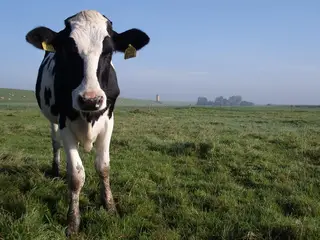
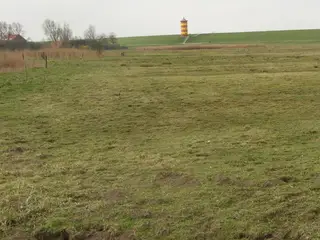
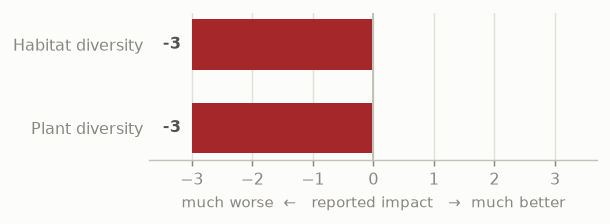
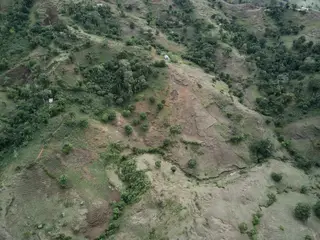
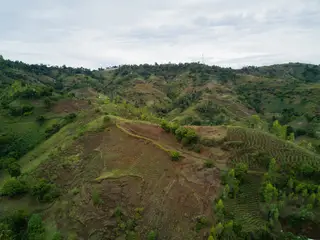
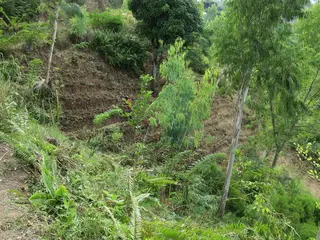
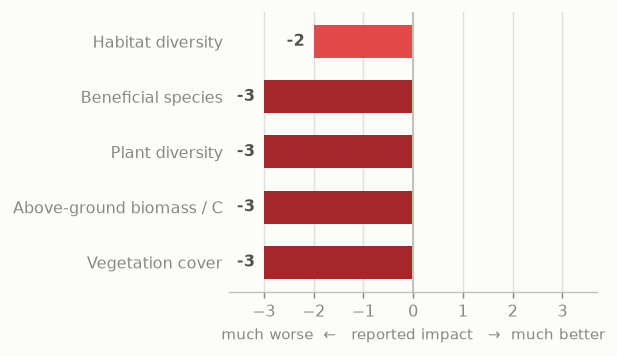
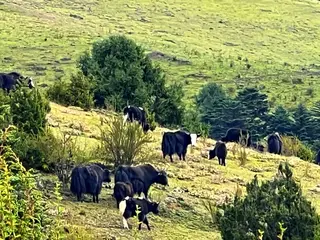
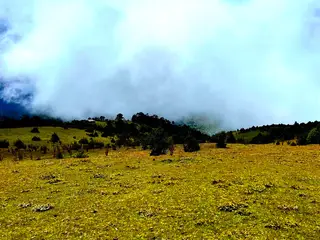
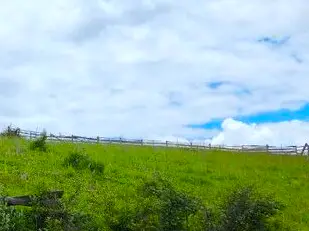
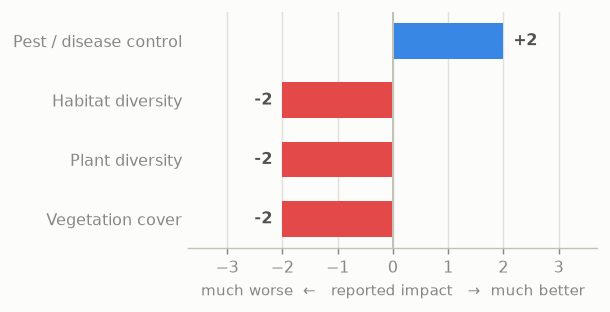
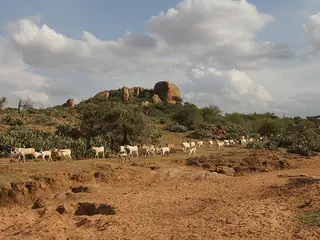
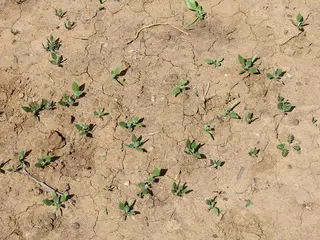
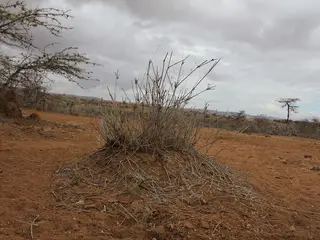
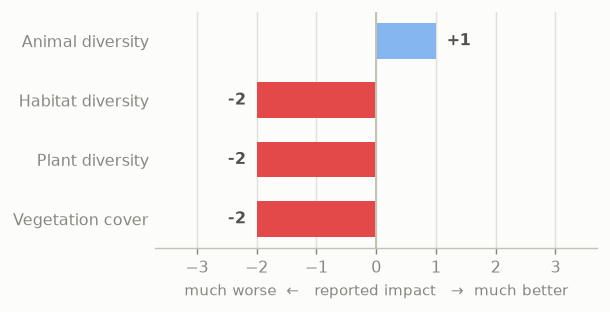
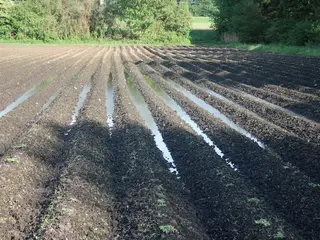
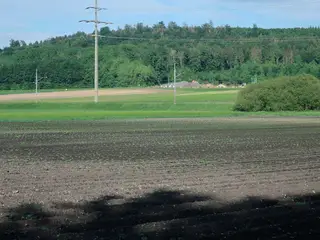
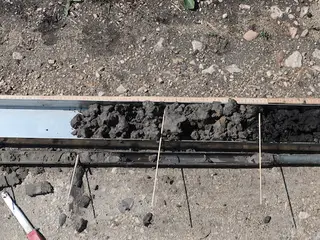
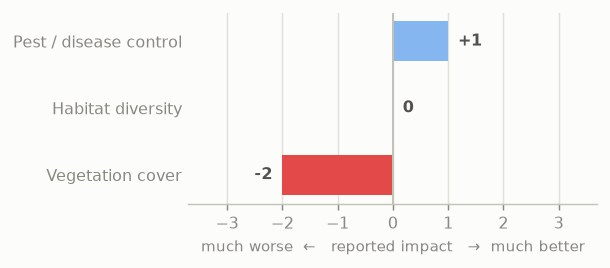

In [10]:
CARD   = ("margin:0 0 30px 0;background:#fcfcfb;color:#0b0b0b;border:1px solid rgba(11,11,11,.10);"
          "border-radius:10px;overflow:hidden;font-family:system-ui,-apple-system,'Segoe UI',sans-serif;")
HEAD   = "display:flex;align-items:center;gap:14px;padding:16px 18px;border-bottom:1px solid #e1e0d9;"
CHIP   = ("flex:0 0 auto;width:78px;padding:9px 0;border-radius:8px;display:flex;flex-direction:column;"
          "align-items:center;justify-content:center;font-weight:700;text-align:center;")
STRIP  = "display:flex;flex-wrap:wrap;gap:14px;padding:16px 18px 4px 18px;"
PHOTO  = "display:block;width:100%;border-radius:6px;border:1px solid rgba(11,11,11,.10);"
CAP    = "margin:5px 0 0 0;font-size:11.5px;line-height:1.45;color:#52514e;"
LEAD   = "margin:0;padding:14px 18px 0 18px;font-size:13.5px;line-height:1.6;"
SPLIT  = "display:flex;flex-wrap:wrap;gap:22px;padding:8px 18px 20px 18px;align-items:flex-start;"
KICKER = ("margin:0 0 7px 0;font-size:11px;color:#898781;text-transform:uppercase;letter-spacing:.07em;"
          "font-weight:600;")


def card(technology_id, row):
    version = record_of(technology_id)
    scores  = long[long.technology_id == technology_id][["indicator", "value", "comment"]]
    photos  = images[images.technology_id == technology_id].sort_values(
        ["is_header", "position"], ascending=[False, True]).head(3)
    definition = i18n(version.get("definition")) or i18n(version.get("description")) or "—"
    landuse = ", ".join((version.get("landuse") or {}).get("value") or []).lower() or "land use not stated"
    chip_colour = SCALE[int(np.clip(round(row.direct_mean), -3, 3))]
    chip_ink = "#fcfcfb" if row.direct_mean <= -1.5 else "#0b0b0b"

    notes = [f"<li style='margin-bottom:7px'><b>{INDICATOR_LABELS[note.indicator]} "
             f"({signed(note.value)}):</b> {' '.join(str(note.comment).split())}</li>"
             for note in scores.itertuples()
             if note.value < 0 and isinstance(note.comment, str) and note.comment.strip()]
    notes_html = (f"<p style='{KICKER}'>Why, in the compiler's words</p>"
                  f"<ul style='margin:0;padding-left:18px;font-size:13px;line-height:1.55'>{''.join(notes)}</ul>"
                  if notes else
                  f"<p style='{KICKER}'>Why</p><p style='margin:0;font-size:13px;color:#898781'>"
                  f"The compiler left no comment on the negative ratings.</p>")

    tiles = ""
    for photo in photos.itertuples():
        data = thumb_bytes(photo.image_id, photo.url_thumb)
        if data is None:
            continue
        caption = " ".join(str(photo.caption).split()) if isinstance(photo.caption, str) else "no caption recorded"
        tiles += (f"<figure style='flex:1 1 190px;max-width:300px;margin:0'>"
                  f"<img src='data:image/webp;base64,{base64.b64encode(data).decode()}' style='{PHOTO}'>"
                  f"<figcaption style='{CAP}'>{caption}</figcaption></figure>")
    if not tiles:
        tiles = "<p style='margin:0;font-size:13px;color:#898781'>This record carries no photographs.</p>"

    return f"""
    <div style="{CARD}">
      <div style="{HEAD}">
        <div style="{CHIP}background:{chip_colour};color:{chip_ink}">
          <span style="font-size:20px;line-height:1">{row.direct_mean:+.2f}</span>
          <span style="font-size:9px;font-weight:500;opacity:.85;margin-top:3px;line-height:1.25">
            mean of {int(row.direct_n)}<br>direct<br>indicators</span>
        </div>
        <div>
          <div style="font-size:17px;font-weight:700;line-height:1.3">{i18n(version.get('name'))}</div>
          <div style="font-size:12.5px;color:#52514e;margin-top:5px;line-height:1.5">
            <b>{row.country_name}</b> &middot; {landuse} &middot;
            all {int(row.n_biodiversity_indicators_rated)} rated indicators average
            {row.biodiversity_score_mean:+.2f} &middot;
            <a href="{record_url(technology_id)}" style="color:#2a78d6;text-decoration:none">record {technology_id} &#8599;</a>
          </div>
        </div>
      </div>
      <div style="{STRIP}">{tiles}</div>
      <p style="{LEAD}">{definition}</p>
      <div style="{SPLIT}">
        <div style="flex:1 1 330px;min-width:290px">
          <p style="{KICKER}">Every indicator the compiler rated</p>
          <img src="data:image/png;base64,{indicator_chart(scores)}" style="display:block;width:100%;max-width:430px">
        </div>
        <div style="flex:1 1 300px;min-width:280px">{notes_html}</div>
      </div>
    </div>"""


display(HTML("".join(card(technology_id, row) for technology_id, row in selected.iterrows())))

### What the five cases have in common

Five unrelated practices on four continents, but the records tell one story three times over:
**biodiversity was traded away for something the land user wanted more.**

* **Germany, drainage of coastal areas (−3.00).** Land reclaimed from the sea in the 19th and 20th
  century, now lying below sea level and drained artificially. Plant diversity −3, *"reduced crop
  diversity"*; habitat diversity −3, *"increased habitat fragmentation"*. The trade is the oldest one
  in land management: a wetland turned into farmland.
* **Haiti, weeded / ploughed crop (−2.80).** The most thoroughly negative record in the corpus —
  five indicators rated, four of them −3. Manual weed control with pickaxes and hoes on very steep
  south-facing slopes near Léogâne, which strips the ground bare exactly when the rains arrive. The
  photo captions make the point the scores do: *"at the time of implementation, the earth is bare
  and vulnerable"*.
* **Bhutan, managed burning of rangeland (−2.00).** A traditional practice: burning *tsamdro* to
  clear unpalatable shrubs so that yaks and cattle get better fodder. The compiler is explicit that
  the loss is deliberate — trees and shrubs *"are intentionally removed"* — so vegetation cover,
  plant diversity and habitat diversity are all −2. Note the +2 on pest control, the very indicator
  section 3 warns about, here used in the ordinary direction; it is what lifts the eight-indicator
  mean to −1.00.
* **Kenya, Makurian group ranch grazing (−1.25).** The odd one out, and the most interesting: the
  damage is not done by the technology. *Opuntia*, an invasive cactus, is driving out native
  vegetation and drawing in elephants that break fences and destroy trees. The compiler is rating
  what is happening to the site, not what the practice did to it.
* **Switzerland, arable rotation on peaty soil (−1.00).** The mildest of the five, and the one that
  reads most like a farm diary: waterlogging over an impermeable clay layer, vegetation cover −2, and
  a photograph of standing water on the potato field. The record is written in German although the
  questionnaire files it under the English key — a reminder that `i18n()` returns the text that is
  there, not the language it was asked for.

Four of the five are **deliberate trade-offs, not failures**: drainage, weeding, burning and
cultivation each did what the land user intended. Only Makurian describes damage arriving from
outside. That distinction is invisible in the score and lives entirely in the free text, which is why
the cards carry the comments next to the numbers.

## 5. What this does and does not show

* **41 negative cases, but 15 readable ones.** The plain reading of "biodiversity below zero" gives
  41 technologies. Once the two indicators whose sign is not used consistently are set aside, 15
  remain — and two technologies the plain reading *excludes* turn out to belong. Any count of
  negative biodiversity outcomes in this corpus depends on that decision, so it should be stated
  rather than assumed.
* **Every score is one person's opinion of their own project.** There are no control plots and no
  independent assessment. A compiler who records a −3 is being candid about a practice they chose to
  document; a compiler who records nothing may simply never have asked the question. Absence of a
  negative is not evidence of no harm.
* **The sample is tiny and self-selected.** Five cases out of 1,540 records illustrate; they cannot
  support a claim about which practices harm biodiversity. The whole negative tail is 41 records,
  too few and too thinly spread across countries and land uses to model.
* **The photographs are evidence of the site, not of the impact.** They show what the place looked
  like to the compiler on a day of their choosing. `photographs_as_evidence.ipynb` in this repository
  works through what the photo corpus can and cannot carry.

**Where the numbers come from:** `technologies_biodiversity.csv` and `biodiversity_impacts_long.csv`
for the scores, `images_index.csv` plus the thumbnail cache for the photographs, and
`data/raw/technologies/<id>.json` for the definitions and comments the CSVs do not keep. All of it is
built by `wocat_api/fetch.py`.